<a href="https://colab.research.google.com/github/pedroantoniolli-ops/Infnet/blob/main/PD_PedroAntoniolli_ValidacaoModelosClusterizacaoDados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Parte 1 (Infraestrutura) se encontra no Github em
[pedroantoniolli-ops/Infnet: Repositorio Infnet]

**Bibliotecas Necessarias **

In [97]:
# Célula: imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
%matplotlib inline


**Versoes dos componentes**

In [98]:
print("Numpy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Seaborn version:", sns.__version__)


Numpy version: 2.0.2
Pandas version: 2.2.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2


**Parte 2: Escolha da Base de Dados**

1. Será utilizada a base de dados do Kaggle de Mall Customers por ser boa para clusterização multivariada (Idade, Renda anual, score de gastos). Esta disponivel no link
https://www.kaggle.com/datasets/shwetabh123/mall-customers

**Justificativa:**  Dataset bom para clusterização multivariada (Idade, Renda Anual, score de gastos). Alem disso, são adequadas para mostrar pré-processamento, gráficos, normalização, execução de KMeans e DBSCAN, e interpretação dos resultados

Instalar a library do Kaggle e kagglehub

In [99]:
## install kaggle

!pip install kaggle

Instalar Kagglehub e importar

In [100]:

## instalar kagglehub e importar

!pip install kagglehub
import kagglehub


Importar o dataframe mall-customers do kaggle

In [101]:
## abrindo o arquivo diretamente do kaggle

## file_path = 'https://www.kaggle.com/datasets/shwetabh123/mall-customers'

consumidor_path = kagglehub.dataset_download("shwetabh123/mall-customers")



Using Colab cache for faster access to the 'mall-customers' dataset.


In [102]:
print("Path to dataset files:", consumidor_path)

Path to dataset files: /kaggle/input/mall-customers


In [103]:
!ls $consumidor_path -lh


total 8.0K
-rw-r--r-- 1 1000 1000 4.2K Dec  7 14:14 Mall_Customers.csv


criar um dataframe local de nome df_ctrdata

In [104]:
## criar um dataframe local csv com base no que foi baixado do Kaggle

df_ctrdata = pd.read_csv(f"{consumidor_path}/Mall_Customers.csv")
df_ctrdata.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Verificar o nome das colunas do dataframe

In [105]:
## verifica o nome das colunas do dataframe

df_ctrdata.columns


Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [106]:
## verifica quantos clientes existem no dataframe

df_ctrdata['CustomerID'].nunique()

200

Criacao dos graficos

In [107]:
## criacao do grafico de variaveis

df_ctrdata.values


array([[1, 'Male', 19, 15, 39],
       [2, 'Male', 21, 15, 81],
       [3, 'Female', 20, 16, 6],
       [4, 'Female', 23, 16, 77],
       [5, 'Female', 31, 17, 40],
       [6, 'Female', 22, 17, 76],
       [7, 'Female', 35, 18, 6],
       [8, 'Female', 23, 18, 94],
       [9, 'Male', 64, 19, 3],
       [10, 'Female', 30, 19, 72],
       [11, 'Male', 67, 19, 14],
       [12, 'Female', 35, 19, 99],
       [13, 'Female', 58, 20, 15],
       [14, 'Female', 24, 20, 77],
       [15, 'Male', 37, 20, 13],
       [16, 'Male', 22, 20, 79],
       [17, 'Female', 35, 21, 35],
       [18, 'Male', 20, 21, 66],
       [19, 'Male', 52, 23, 29],
       [20, 'Female', 35, 23, 98],
       [21, 'Male', 35, 24, 35],
       [22, 'Male', 25, 24, 73],
       [23, 'Female', 46, 25, 5],
       [24, 'Male', 31, 25, 73],
       [25, 'Female', 54, 28, 14],
       [26, 'Male', 29, 28, 82],
       [27, 'Female', 45, 28, 32],
       [28, 'Male', 35, 28, 61],
       [29, 'Female', 40, 29, 31],
       [30, 'Female', 23

Realizar Analise Exploratoria e Faixa Dinamica dos dados

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


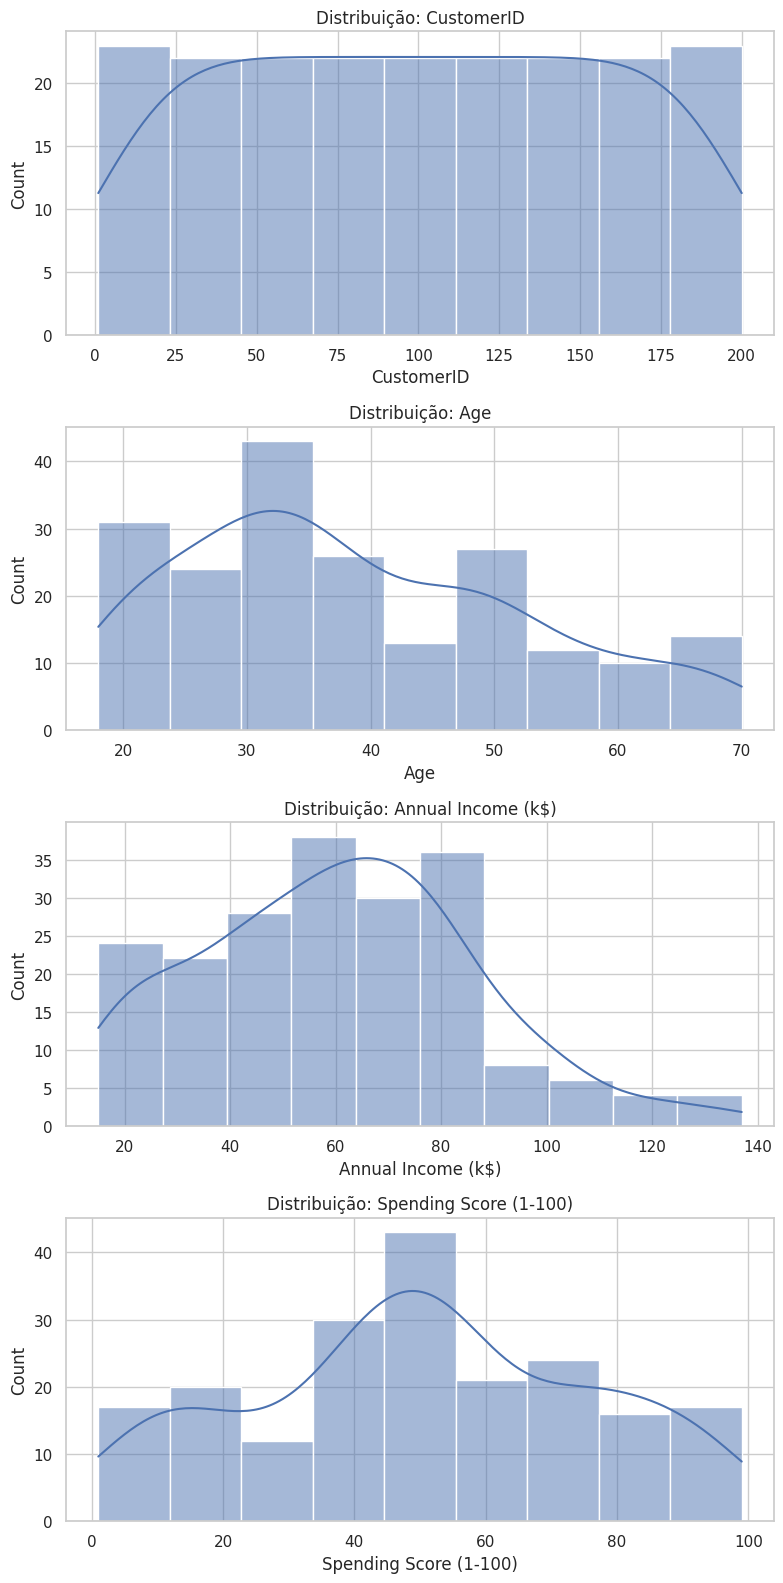

In [108]:
# Estatísticas descritivas
df = df_ctrdata
display(df.describe(include='all'))

# Histograma das variáveis numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(len(num_cols), 1, figsize=(8, 4*len(num_cols)))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"Distribuição: {col}")
plt.tight_layout()


Utilizar Scatter / Pairplot para ver as relacoes

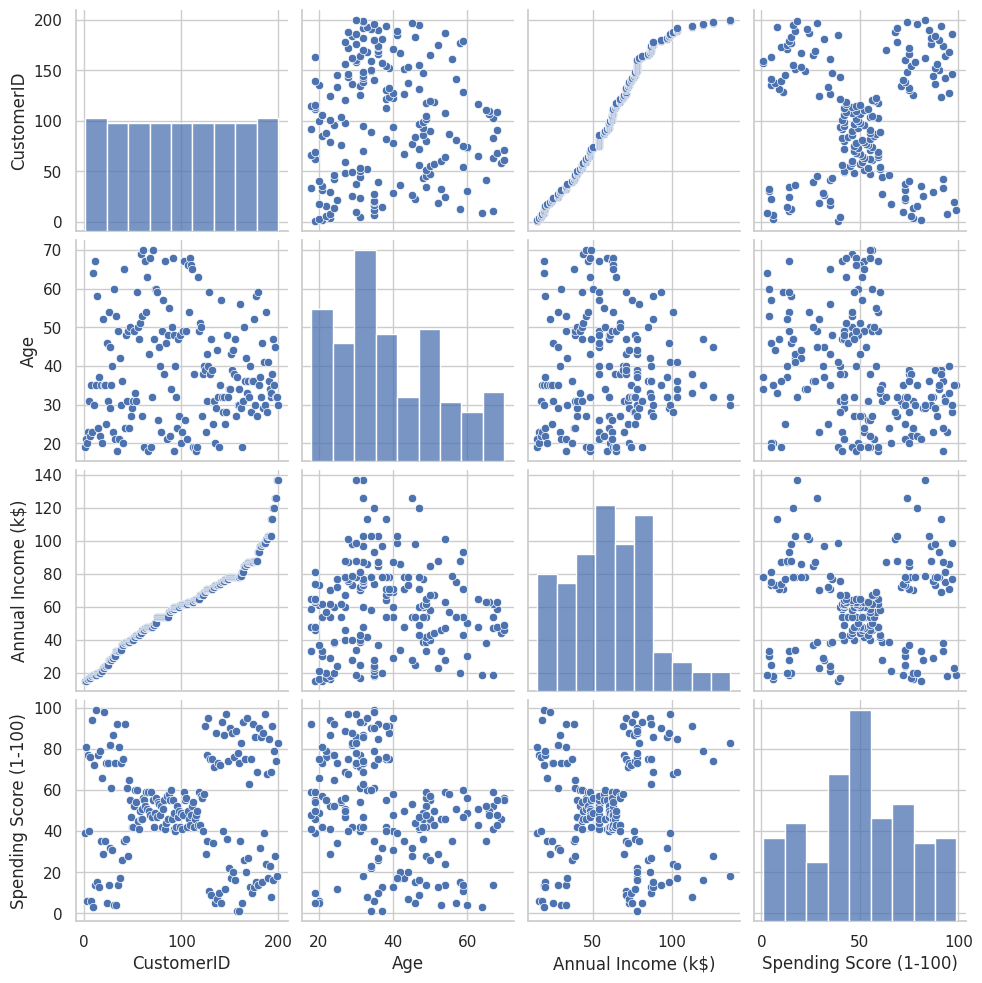

In [109]:
sns.pairplot(df[num_cols])


Pré-processamento (limpeza, tratamento de nulos, scaling)

In [110]:
# 1) lidar com nulos
df = df.dropna()  # ou imputação se necessário

# 2) selecionar colunas para cluster
features = ['Annual Income (k$)', 'Spending Score (1-100)']  # ajuste conforme dataset
X = df[features].values

# 3) escala
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Explorar PCA para visualizar dimensão reduzida

Text(0, 0.5, 'PC2')

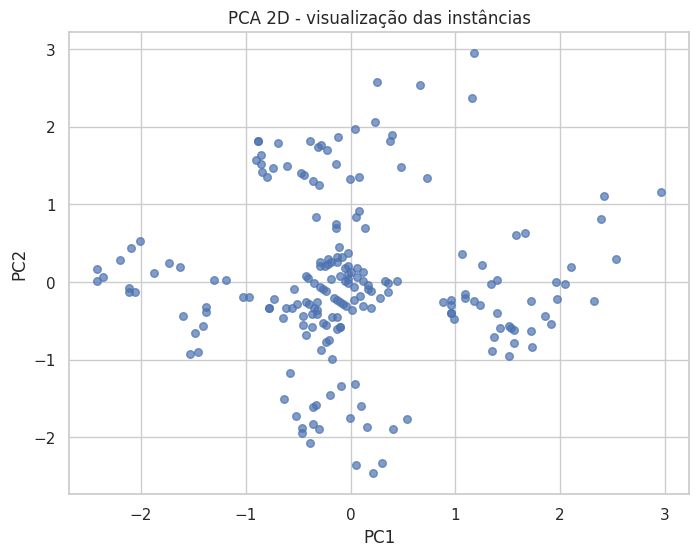

In [111]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=30, alpha=0.7)
plt.title("PCA 2D - visualização das instâncias")
plt.xlabel("PC1"); plt.ylabel("PC2")


**Parte 3 - Clusterizacao**

Para os dados pré-processados da etapa anterior você irá:

1.	Realizar o agrupamento dos dados, escolhendo o número ótimo de clusters. Para tal, use o índice de silhueta e as técnicas:

  a.	K-Médias
  b.	DBScan

2.	Com os resultados em mão, descreva o processo de mensuração do índice de silhueta. Mostre o gráfico e justifique o número de clusters escolhidos.

3.	Compare os dois resultados, aponte as semelhanças e diferenças e interprete.

4.	Escolha mais duas medidas de validação para comparar com o índice de silhueta e analise os resultados encontrados. Observe, para a escolha, medidas adequadas aos algoritmos.

5.	Realizando a análise, responda: A silhueta é um o índice indicado para escolher o número de clusters para o algoritmo de DBScan?


K-Means: escolher k com Silhouette (e elbow) + execução

Elbow + Silhouette

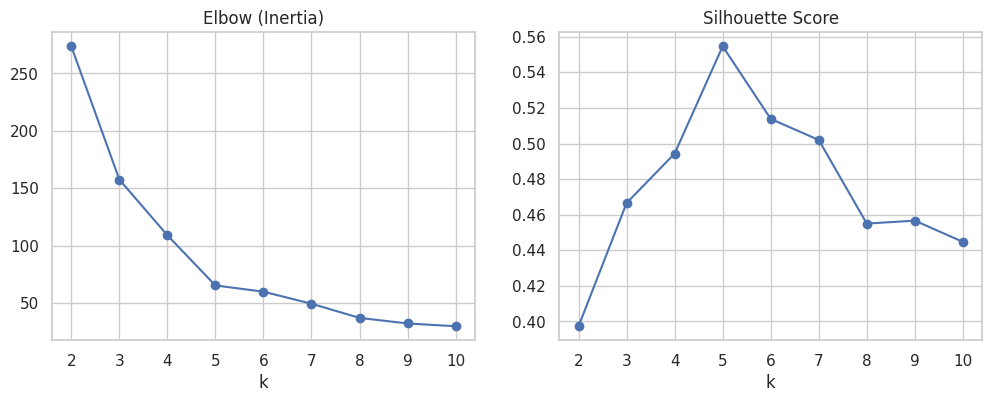

In [112]:
# Elbow (inércia) e Silhouette
inertias = []
sil_scores = []
K = range(2,11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Plot
fig, ax1 = plt.subplots(1,2, figsize=(12,4))
ax1[0].plot(K, inertias, '-o'); ax1[0].set_title('Elbow (Inertia)'); ax1[0].set_xlabel('k')
ax1[1].plot(K, sil_scores, '-o'); ax1[1].set_title('Silhouette Score'); ax1[1].set_xlabel('k')
plt.show()


**Pelo metodo do cotovelo e da silhueta, o numero ideal de clusters seria 5.**

**Melhor k e fit final**

Text(0.5, 1.0, 'KMeans k=5 (Silhouette=0.555)')

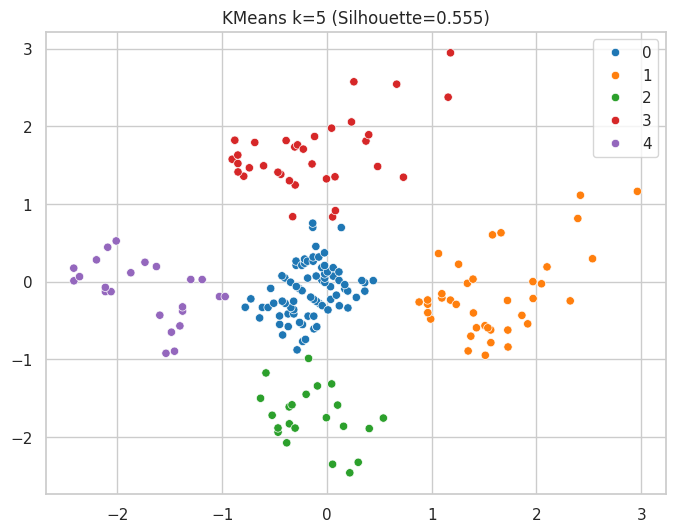

In [113]:
best_k = int(np.argmax(sil_scores) + 2)  # +2 porque range começa em 2
km = KMeans(n_clusters=best_k, random_state=42)
labels_km = km.fit_predict(X_scaled)

# visualizar
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_km, palette='tab10', legend='full')
plt.title(f'KMeans k={best_k} (Silhouette={silhouette_score(X_scaled, labels_km):.3f})')


**Analise das semelhancas e diferencas entre o metodo Silhouette e Ellbow**

Ambos servem para escolher o número ideal de clusters (k), ou seja, sao metodos de validacao de clusterizacao, usados principalmente com o K-Means.
Dessa forma ambos analisam a qualidade da separacao dos clusters, porem de maneiras distintas, e permitem chegar ao mesmo resultado, validando se o agrupamento esta coerente.
Assim, ambos rodam o K-Means para k=1, 2, 3, ... e analisam o comportamento das metricas.
Alem disso, ambos sao metodos heuristicos, nao garantindo a escolha perfeita, mas dando forte indicacao da quantidade de clusters.

As diferencas recaem sobre a forma do funcionamento dos metodos, sendo que o Elbow usa o Within-Cluster Sum of Squares (WCSS), medindo quanta variabilidade ainda existe dentro dos clusters. Dessa forma, quanto mais clusters, menor o WCSS.

Ja o metodo Silhouette mede o quão bem cada ponto está alocado ao seu cluster, avaliando simultaneamente coesão (quão perto estão do seu cluster) e separação (quão afastados estão dos outros clusters). Os valores vao de -1 a 1, sendo 1 cluster perfeito, e 0 clusters sobrepostos. O negativo indica ponto no cluster errado. Portanto, o melhor k é o que maximiza a média da silhueta. O objetivo seria, portanto, encontrar o ponto onde adicionar mais clusters não melhora muito o “cotovelo”.

Em resumo, o Elbow requer interpretacao visual subjetiva, uma vez que o cotovelo pode nao aparecer claramente, dependendo dos dados. Alem disso, pode indicar multiplos valores de K. Funciona bem quando os clusters sao esfericos e bem separados, mas pouco robusto a outliers. Ja o metodo Silhouette apresenta interpretacao quantitativa e objetiva, indicando normalmente um unico valor para k, sendo assim mais robusto, detectanto clusters mal formados, e indicando se o cluster global esta ruim.

Dessa forma, pelos motivos apresentados, o metodo preferivel seria o de Silhouette.

DBSCAN: encontrar epsilon via k-NN distance e rodar

Encontrar eps (gráfico k-dist)

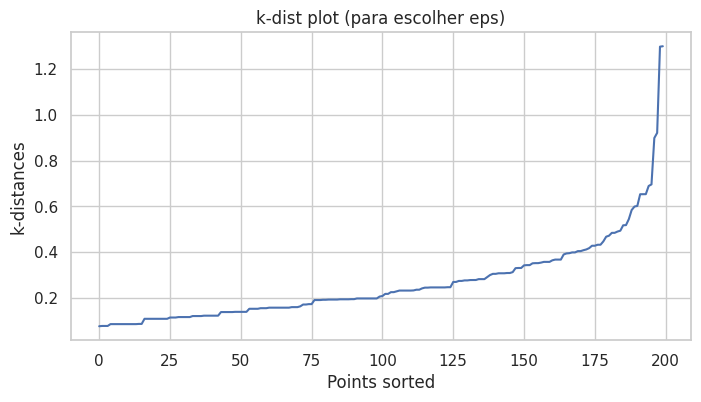

In [114]:
# k para k-dist tipicamente min_samples (ex: 4)
min_samples = 5
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
dist_k = np.sort(distances[:, -1])
plt.figure(figsize=(8,4))
plt.plot(dist_k)
plt.title('k-dist plot (para escolher eps)')
plt.ylabel('k-distances')
plt.xlabel('Points sorted')
plt.show()


Como o DBSCAN esta demorando muito, significa que ha hiperparametros, entao seria necessario normalizar

In [115]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)


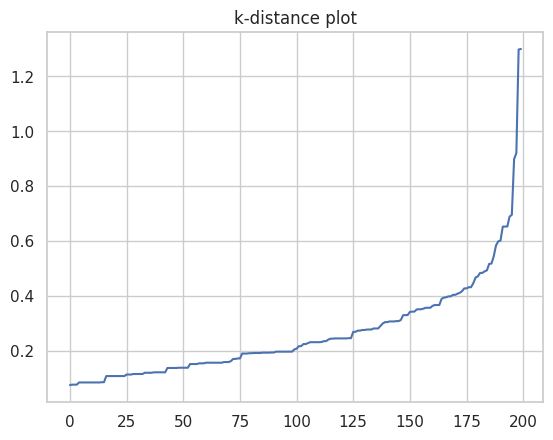

In [116]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, -1])
plt.plot(distances)
plt.title("k-distance plot")
plt.show()



Escolhendo a curva do cotovelo como eps => 0,7 para rodar o DBSCAN

In [117]:
db = DBSCAN(
    eps=0.7,
    min_samples=min_samples,
    algorithm='kd_tree'
)


Reduzindo a dimensionalidade para diminuir a lentidao do DBSCAN

In [118]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)


In [119]:
eps = 0.7 # Setting a default value for eps
db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X_pca)

Rodar DBSCAN (eps)

In [120]:
db = DBSCAN(eps=eps, min_samples=min_samples)
labels_db = db.fit_predict(X_scaled)

# quantos clusters (excluindo ruído = -1)
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = list(labels_db).count(-1)

print(f"Clusters: {n_clusters_db}, Noise points: {n_noise}")

# Se houver pelo menos 2 clusters, calcule silhouette (silhouette ignora rótulos -1 automaticamente)
if n_clusters_db >= 2:
    sil_db = silhouette_score(X_scaled[labels_db!=-1], labels_db[labels_db!=-1])
    print("Silhouette (sem ruído):", sil_db)
else:
    print("Silhouette não aplicável (menos de 2 clusters)")

Clusters: 1, Noise points: 0
Silhouette não aplicável (menos de 2 clusters)


Visualização

Text(0.5, 1.0, 'DBSCAN eps=0.7 - clusters=5 - noise=0')

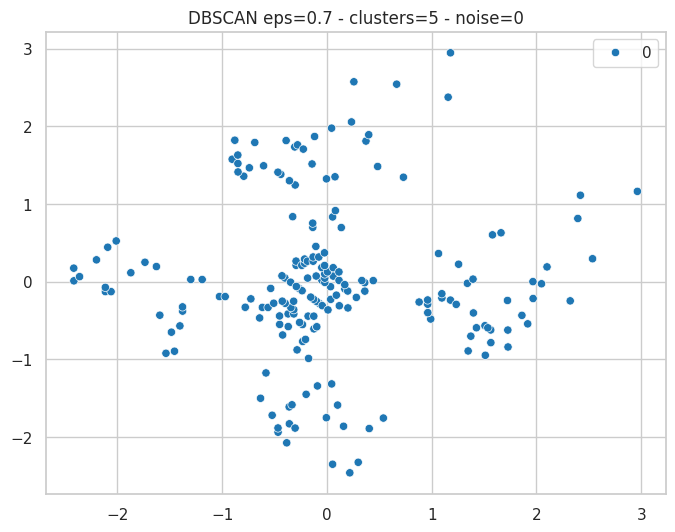

In [121]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_db, palette='tab10', legend='full')
plt.title(f'DBSCAN eps={eps} - clusters={5} - noise={n_noise}')


Métricas adicionais e interpretação

**Calcule as três métricas para comparar: Silhouette, Davies_Bouldin, Calinski_Harabasz**

In [122]:
# KMeans metrics
sil_km = silhouette_score(X_scaled, labels_km)
db_km = davies_bouldin_score(X_scaled, labels_km)
ch_km = calinski_harabasz_score(X_scaled, labels_km)

print("KMeans: silhouette=%.3f, Davies-Bouldin=%.3f, Calinski-Harabasz=%.3f" % (sil_km, db_km, ch_km))

# DBSCAN: calcular métricas somente para pontos com rótulo != -1
mask = labels_db != -1
filtered_labels_db = labels_db[mask]

# Check if there are at least 2 non-noise points AND at least 2 distinct clusters among them
if len(filtered_labels_db) >= 2 and len(set(filtered_labels_db)) >= 2:
    sil_db = silhouette_score(X_scaled[mask], filtered_labels_db)
    db_db = davies_bouldin_score(X_scaled[mask], filtered_labels_db)
    ch_db = calinski_harabasz_score(X_scaled[mask], filtered_labels_db)
    print("DBSCAN (sem ruído): silhouette=%.3f, Davies-Bouldin=%.3f, Calinski-Harabasz=%.3f" % (sil_db, db_db, ch_db))
else:
    print("DBSCAN: métricas não aplicáveis - poucos pontos em clusters ou menos de 2 clusters distintos")

KMeans: silhouette=0.555, Davies-Bouldin=0.572, Calinski-Harabasz=248.649
DBSCAN: métricas não aplicáveis - poucos pontos em clusters ou menos de 2 clusters distintos


**Interpretação:**

**Silhouette:** Com valor de 0,555 mede a coesão em comparacao com a separação ([−1,1]). Se torna um bom indicativo para KMeans. Ja para o DBSCAN merece atencao porque pode apresentar ruído (-1), que deve ser removido antes do cálculo. Adicionalmente, silhueta pode favorecer particionamentos mais esféricos.

**Davies-Bouldin:** Com valor de 0,572 sta metrica penaliza a similaridade entre clusters, considerando que menor distancia seria melhor.

**Calinski-Harabasz:** Com valor de 248,649 Esta metrica considera razão entre a dispersões entre e intra-cluster, ou seja, quanto maior melhor.

**Escolha do metodo de validacao de clusterizacao:**
Pelos resultados apresentados o metodo Silhouette apresenta interpretacao quantitativa e objetiva, indicando normalmente um unico valor para k, sendo assim mais robusto, detectanto clusters mal formados, e indicando se o cluster global esta ruim.

Dessa forma, pelos motivos apresentados, o metodo preferivel seria o de Silhouette.


**Como medir e justificar número ótimo de clusters (KMeans)**

Usando Elbow (inertia) para ver o ponto de amortecimento (cotovelo).

Usando Silhouette para valor numérico de qualidade — escolhendo k com silhouette máximo (ou local máximo).

E validar com Davies-Bouldin e Calinski-Harabasz se as três métricas concordarem. Dessa forma, a decisão fica mais robusta.

**A silhueta é indicada para escolher número de clusters para DBSCAN?**

Não é ideal para DBSCAN. DBSCAN determina clusters por densidade — número de clusters e ruído dependem de eps e min_samples. Silhueta pode ajudar após remover ruído para comparar configurações de eps.

Entretanto, a silhueta pressupõe clusters relativamente convexos/esféricos.

DBSCAN detecta formas arbitrárias; silhueta pode subestimar qualidade quando clusters têm formas complexas.

**Recomendação:** usar silhouette como uma das evidências, mas complemente com análise visual, estabilidade (variação das partições ao alterar eps) e métricas como Davies–Bouldin e contagem/percentual de ruído.

**Parte 4: Séries temporais — agrupar 10 séries por máxima correlação cruzada**

1.	Um determinado problema, apresenta 10 séries temporais distintas. Gostaríamos de agrupá-las em 3 grupos, de acordo com um critério de similaridade, baseado no valor máximo de correlação cruzada entre elas. Descreva em tópicos todos os passos necessários.

2.	Para o problema da questão anterior, indique qual algoritmo de clusterização você usaria. Justifique.

3.	Indique um caso de uso para essa solução projetada.

4.	Sugira outra estratégia para medir a similaridade entre séries temporais. Descreva em tópicos os passos necessários.


**Objetivo**

Agrupar 10 séries temporais em 3 grupos usando máxima correlação cruzada (cross-correlation maximum) como medida de similaridade.

**Passos (em tópicos)**

**1. Pré-processamento:**

Verificar e tratar valores perdidos (imputar ou remover).

Opcional: desazonalizar se necessário (depende do objetivo).

Normalizar cada série (z-score) para que amplitude não distorça correlação.

**2. Cálculo da função de correlação cruzada entre par (i,j):**

Para séries x e y, calcule cross_corr(lag) para lags em um intervalo razoável (ex: -max_lag..+max_lag).

Tome max_corr_ij = max(|cross_corr(lag)|) ou só max(cross_corr(lag)) se o sinal for relevante.

Opcional: guardar lag_at_max para análise de defasagem entre séries.

**3. Matriz de distância/similaridade:**

Para similaridade S_ij = max_corr_ij.

Converter para distância: D_ij = 1 - S_ij (se S em [-1,1], ajuste: use (1 - S_ij)/2 se incluir negativas).

**4. Escolha do algoritmo de clusterização:**

Algoritmos baseados em distância: Hierarchical (agglomerative), K-Medoids (PAM) ou Spectral Clustering com matriz de similaridade.

Justificativa: distâncias derivadas de correlação não respeitam propriedades euclidianas — KMeans não é adequado porque assume média euclidiana; K-medoids/Hierarchical usam apenas distâncias/similaridade.

**5. Clusterização:**

Rodar AgglomerativeClustering com affinity='precomputed' (ou metric='precomputed') usando D_ij.

Escolher número de clusters (k=3) — pode validar com silhouette (com distância), ou dendrograma para justificar corte.

**6. Validação e interpretação:**

Plotar heatmap da matriz de correlação máxima, dendrograma, e série média por cluster.

Mostrar exemplos de séries por cluster e lags médios.

In [123]:
from scipy.signal import correlate
from scipy.spatial.distance import squareform
from sklearn.cluster import AgglomerativeClustering
import numpy as np

def max_cross_corr(x, y, max_lag=None):
    # assume x,y 1D numpy, same length
    n = len(x)
    if max_lag is None:
        max_lag = n//4
    # normalize
    x = (x - x.mean())/x.std()
    y = (y - y.mean())/y.std()
    lags = np.arange(-max_lag, max_lag+1)
    # Pad series for correlation to handle lags
    # np.corrcoef needs same length arrays, so trim to overlapping parts
    corr = [np.corrcoef(x[max(0,lag):min(n,n+lag)], y[max(0,-lag):min(n,n-lag)])[0,1]
            for lag in lags]
    corr = np.array(corr)
    return np.nanmax(np.abs(corr))  # retorna valor absoluto máximo

# Supondo matriz series: series_list = [s1, s2, ..., s10]
# Generating 10 sample time series for demonstration
np.random.seed(42) # for reproducibility
series_length = 100
series_list = [np.random.randn(series_length).cumsum() for _ in range(10)]

m = len(series_list)
S = np.zeros((m,m))
for i in range(m):
    for j in range(i+1,m):
        val = max_cross_corr(series_list[i], series_list[j], max_lag=30)
        S[i,j]=S[j,i]=val

# distancia
D = 1 - S  # ou (1-S)/2 se S em [-1,1]
# cluster
cl = AgglomerativeClustering(n_clusters=5, metric='precomputed', linkage='average')
labels = cl.fit_predict(D)


**Algoritmo recomendado**

**Agglomerative clustering (linkage average/complete) ou K-medoids (PAM)** — ambos trabalham com matrizes de distância pré-computadas e não assumem média euclidiana, portanto são adequados para distância baseada em correlação.

**Caso de uso**

**Agrupar sensores industriais** cujas séries representam sinais de vibração/temperatura para identificar grupos de máquinas com comportamento similar (manutenção preditiva).

**Segmentação de usuários por séries de consumo** (energia elétrica), identificar clientes com padrões semelhantes ao longo do tempo.

**Alternativa de similaridade**

**Dynamic Time Warping (DTW):** mede similaridade alinhando no tempo; resistente a desfasagens e variação de velocidade.

Passos: padronizar séries → calcular matriz de distâncias DTW (ex: via tslearn.metrics.cdist_dtw) → usar Agglomerative/K-medoids.

DTW é útil quando séries têm padrões semelhantes porém deslocados ou esticados no tempo.

**REFERENCIAS**

KODINARIYA. T. Review on determining number of Cluster in K-Means Clustering.
International Journal of Advance Reserach in Computer Science and
Management Studies. Rajkot, India, v.1, n. 6, p. 90-95, nov. 2013

LOPES. G R. Validacao de Modelos de Clusterizacao. MIT Inteligencia Artificial. Notas de Aula. 2025.

ROCHA, H. V; LACHI, R. L. Aspectos Básicos de Clustering: Conceitos e
Técnicas. Relatório Técnico IC-05-003, UNICAMP – Universidade Estadual de
Campinas, Campinas, fevereiro, 2005.

SANTANA, F. Entenda o Algoritmo K-Means e Saiba como Aplicar essa Técnica.
Minerando Dados. 2017. Disponível em: https://minerandodados.com.br/entenda-oalgoritmo-k-means/. Acesso em: 03 de maio de 2020.

SCIKIT-LEARN (biblioteca do software de programação Python) https://scikitlearn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html. Acesso em: 07 de dezembro de 2025.

WANG, F; FRANCO-PENYA, H-H; KELLEHER, D. J; PUGH, J; ROSS, R. An
Analysis of the Application of Simplified Silhouette to the Evaluation of k-means Clustering Validation. School of Computing, Dublin Institute of Technology, Ireland, jul. 2017



